# 03 — Stats and plots

Paired comparisons, mixed-effects model with `t*condition` interaction, effect sizes (Cohen's d_z), and the headline presentation figures.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', context='talk')

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data') if os.path.basename(os.getcwd()) == 'src' else 'data'
FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), 'figs') if os.path.basename(os.getcwd()) == 'src' else 'figs'
os.makedirs(FIG_DIR, exist_ok=True)
pf = pd.read_parquet(os.path.join(DATA_DIR, 'revision_pairs_features.parquet'))
print(pf.shape)
print(pf['condition'].value_counts().to_dict())

(267, 89)
{'stairs': 157, 'random_reread': 110}


## Paired tests and Cohen's d_z by feature and condition

In [2]:
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath('.')) + '/src' if os.path.basename(os.getcwd())!='src' else '.')
import features as F

FEATURES = F.FEATURE_COLUMNS + [
    'content_score','language_score','similarity_score','containment_score',
]

def cohen_dz(deltas):
    d = np.asarray(deltas, dtype=float)
    d = d[~np.isnan(d)]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return d.mean() / d.std(ddof=1)

rows = []
for feat in FEATURES:
    dcol = f'{feat}_delta'
    if dcol not in pf.columns:
        continue
    for cond in ['stairs','random_reread']:
        sub = pf[pf['condition']==cond][dcol].dropna()
        if len(sub) < 2:
            continue
        t_stat, p_t = stats.ttest_1samp(sub, 0.0)
        try:
            w_stat, p_w = stats.wilcoxon(sub, zero_method='wilcox')
        except ValueError:
            w_stat, p_w = (np.nan, np.nan)
        rows.append({
            'feature': feat,
            'condition': cond,
            'n': len(sub),
            'mean_delta': sub.mean(),
            'sd_delta': sub.std(ddof=1),
            'cohens_dz': cohen_dz(sub),
            't': t_stat,
            'p_t': p_t,
            'wilcoxon_W': w_stat,
            'p_wilcoxon': p_w,
        })
paired_stats = pd.DataFrame(rows)
paired_stats.to_csv(os.path.join(DATA_DIR, 'paired_stats.csv'), index=False)
paired_stats

/opt/conda/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


,feature,condition,n,mean_delta,sd_delta,cohens_dz,t,p_t,wilcoxon_W,p_wilcoxon
0,word_count,stairs,157,23.936306,25.676159,0.932239,11.680916,4.781327e-23,276.0,2.226737e-24
1,word_count,random_reread,110,5.645455,16.678056,0.338496,3.550176,5.696327e-04,0.0,2.930525e-04
2,sentence_count,stairs,157,1.165605,1.399850,0.832665,10.433257,1.156816e-19,556.0,1.922231e-19
3,sentence_count,random_reread,110,0.300000,0.904119,0.331815,3.480102,7.218218e-04,0.0,5.760403e-04
4,mtld,stairs,157,2.137253,18.082267,0.118196,1.480992,1.406256e-01,4854.0,5.902731e-02
5,mtld,random_reread,110,1.911061,11.814408,0.161757,1.696520,9.264159e-02,42.0,1.024344e-01
6,science_strong,stairs,157,0.143594,2.180034,0.065868,0.825320,4.104503e-01,5074.0,7.709225e-01
7,science_strong,random_reread,110,0.063362,1.297472,0.048835,0.512182,6.095599e-01,65.0,8.767217e-01
8,science_moderate,stairs,157,0.451462,4.283712,0.105390,1.320538,1.885895e-01,5312.0,2.920016e-01
9,science_moderate,random_reread,110,0.504597,4.174552,0.120875,1.267744,2.075909e-01,55.0,3.087876e-01


## Mixed-effects model: feature ~ t * condition + (1|user) + (1|page)

In [3]:
# Reshape to long form (one row per observation, with a t column).
long_rows = []
for _, r in pf.iterrows():
    base = {'user_id': r['user_id'], 'page_slug': r['page_slug'], 'condition': r['condition']}
    for t_val, suffix in [(1,'t1'),(2,'t2')]:
        obs = dict(base, t=t_val)
        for feat in FEATURES:
            col = f'{feat}_{suffix}'
            if col in pf.columns:
                obs[feat] = r[col]
        long_rows.append(obs)
long_df = pd.DataFrame(long_rows)
long_df['condition'] = pd.Categorical(long_df['condition'], categories=['random_reread','stairs'])
long_df.to_csv(os.path.join(DATA_DIR, 'revision_pairs_long.csv'), index=False)
print(long_df.shape)
long_df.head()

(534, 29)


,user_id,page_slug,condition,t,word_count,sentence_count,mtld,science_strong,science_moderate,science_weak,...,confusion_strong,confusion_moderate,confusion_weak,critical_thinking_strong,critical_thinking_moderate,critical_thinking_weak,content_score,language_score,similarity_score,containment_score
0,2hrsmtdsvpnutaqxmgdnaaldvq,7-1-the-relatively-recent-arrival-of-economic-...,stairs,1,70.0,2.0,78.415556,0.000000,22.857143,21.428571,...,0.0,1.428571,20.000000,2.857143,28.571429,12.857143,-0.797054,3.142005,0.662562,0.0000
1,2hrsmtdsvpnutaqxmgdnaaldvq,7-1-the-relatively-recent-arrival-of-economic-...,stairs,2,100.0,3.0,60.293224,0.000000,24.000000,20.000000,...,0.0,6.000000,18.000000,5.000000,28.000000,11.000000,-0.236283,3.231656,0.658375,0.0435
2,2hrsmtdsvpnutaqxmgdnaaldvq,7-2-labor-productivity-and-economic-growth,stairs,1,56.0,3.0,57.079964,5.357143,28.571429,14.285714,...,0.0,3.571429,19.642857,5.357143,37.500000,7.142857,-0.093934,2.612348,0.715804,0.0000
3,2hrsmtdsvpnutaqxmgdnaaldvq,7-2-labor-productivity-and-economic-growth,stairs,2,97.0,6.0,55.435243,3.092784,21.649485,21.649485,...,0.0,4.123711,15.463918,4.123711,28.865979,15.463918,0.578476,2.680135,0.852832,0.0000
4,2qmmqqwwa5a7skhydrbq5u67ku,7-1-the-relatively-recent-arrival-of-economic-...,stairs,1,59.0,4.0,88.607273,3.389831,22.033898,22.033898,...,0.0,5.084746,18.644068,3.389831,32.203390,11.864407,-0.779259,2.618597,0.689911,0.0556


In [4]:
# statsmodels MixedLM supports only a single grouping factor; we use user_id.
# This mirrors the LME pattern in itell-data/2024.05-CTTC/src/lme/.
lme_rows = []
for feat in FEATURES:
    d = long_df[['user_id','page_slug','condition','t', feat]].dropna()
    if d[feat].nunique() < 3:
        continue
    try:
        md = smf.mixedlm(f'{feat} ~ t * C(condition, Treatment("random_reread"))',
                         data=d, groups=d['user_id'])
        mdf = md.fit(method='lbfgs', reml=True, disp=False)
    except Exception as e:
        print('skip', feat, e)
        continue
    # interaction term is the row whose name contains both 't' and 'condition'.
    interaction_key = [k for k in mdf.params.index if ':' in k and 't' in k]
    if not interaction_key:
        continue
    k = interaction_key[0]
    lme_rows.append({
        'feature': feat,
        'interaction_term': k,
        'coef': mdf.params[k],
        'se': mdf.bse[k],
        'z': mdf.tvalues[k],
        'p': mdf.pvalues[k],
    })
lme_summary = pd.DataFrame(lme_rows)
lme_summary.to_csv(os.path.join(DATA_DIR, 'lme_interactions.csv'), index=False)
lme_summary

/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


skip mtld Singular matrix
skip science_strong Singular matrix


/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


skip science_weak Singular matrix
skip philosophy_strong Singular matrix


/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


...

/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


skip critical_thinking_moderate Singular matrix
skip critical_thinking_weak Singular matrix


/opt/conda/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


skip similarity_score Singular matrix


,feature,interaction_term,coef,se,z,p
0,word_count,"t:C(condition, Treatment(""random_reread""))[T.s...",18.290851,3.394191,5.388869,7.090248e-08
1,sentence_count,"t:C(condition, Treatment(""random_reread""))[T.s...",0.865605,0.207778,4.166013,3.099728e-05
2,science_moderate,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.053135,1.172767,-0.045308,9.638621e-01
3,philosophy_moderate,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.239309,0.905255,-0.264356,7.915058e-01
4,philosophy_weak,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.249023,0.972556,-0.256050,7.979125e-01
5,negotiate_weak,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.106111,0.782854,-0.135544,8.921820e-01
6,communication_strong,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.191144,0.548232,-0.348655,7.273484e-01
7,confusion_moderate,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.187654,0.386416,-0.485626,6.272324e-01
8,critical_thinking_strong,"t:C(condition, Treatment(""random_reread""))[T.s...",-0.031672,0.469387,-0.067475,9.462036e-01
9,content_score,"t:C(condition, Treatment(""random_reread""))[T.s...",0.276473,0.063540,4.351191,1.354003e-05


## Headline plot: Cohen's d_z by feature and condition

Effect sizes are used so heterogeneous features (counts, rates, existing iTELL scores) can be read on a common axis.

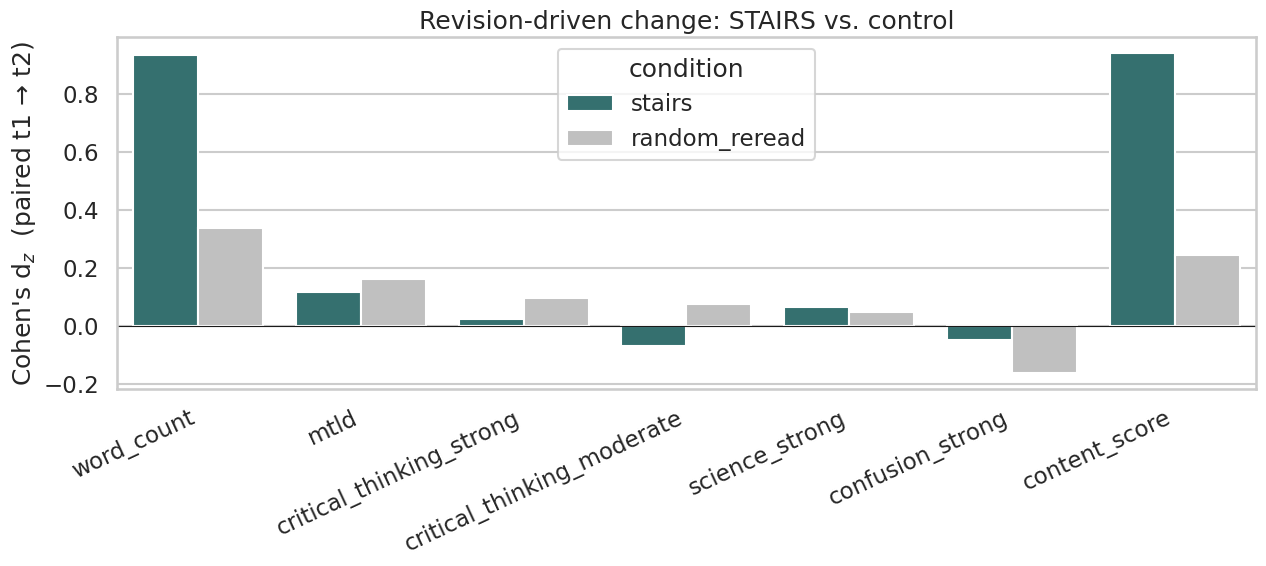

In [5]:
HEADLINE = ['word_count','mtld',
            'critical_thinking_strong','critical_thinking_moderate',
            'science_strong','confusion_strong','content_score']

plot_df = (paired_stats[paired_stats['feature'].isin(HEADLINE)]
           .assign(feature=lambda d: pd.Categorical(d['feature'], categories=HEADLINE, ordered=True))
           .sort_values(['feature','condition']))

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(plot_df, x='feature', y='cohens_dz', hue='condition', ax=ax,
            palette={'stairs':'#2b7a78','random_reread':'#c0c0c0'},
            hue_order=['stairs','random_reread'])
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel("Cohen's d$_z$  (paired t1 → t2)")
ax.set_xlabel('')
ax.set_title('Revision-driven change: STAIRS vs. control')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'headline_effect_sizes.png'), dpi=180)
plt.show()

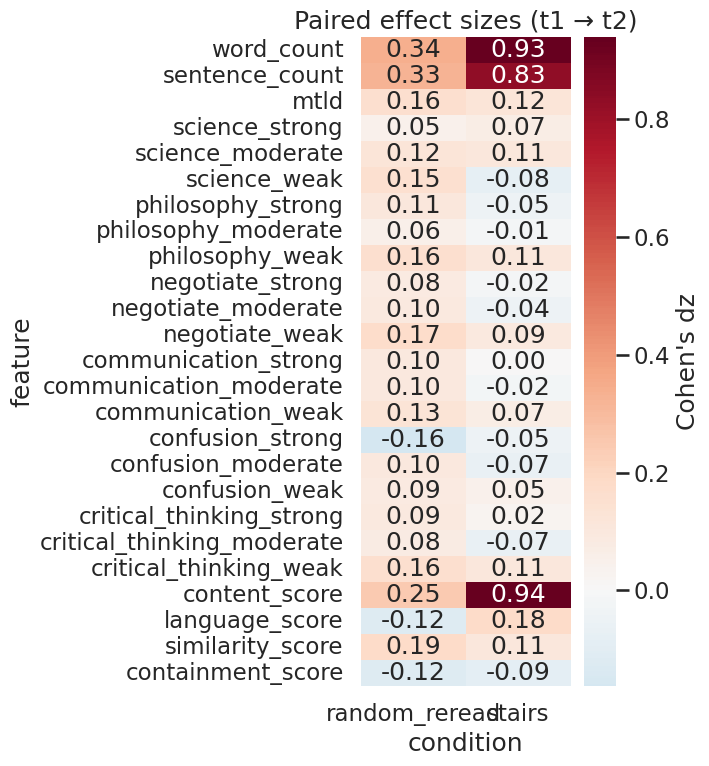

In [6]:
# Effect-size heatmap across all features
piv = paired_stats.pivot(index='feature', columns='condition', values='cohens_dz')
piv = piv.reindex(FEATURES)
fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(piv, annot=True, fmt='.2f', center=0, cmap='RdBu_r', ax=ax, cbar_kws={'label':"Cohen's dz"})
ax.set_title('Paired effect sizes (t1 → t2)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'effect_size_heatmap.png'), dpi=180)
plt.show()

## Qualitative examples — feedback → before → after

In [7]:
stairs_pairs = pf[(pf['condition']=='stairs') & (pf['stairs_feedback'].str.len()>0)].copy()
# Rank by magnitude on a few dimensions of interest.
stairs_pairs['score_combo'] = (stairs_pairs['content_score_delta'].fillna(0).rank()
                                + stairs_pairs['critical_thinking_strong_delta'].fillna(0).rank()
                                + stairs_pairs['word_count_delta'].fillna(0).rank())
examples = stairs_pairs.sort_values('score_combo', ascending=False).head(3)

for _, r in examples.iterrows():
    print('='*80)
    print(f"user={r['user_id'][:8]}  page={r['page_slug']}  "
          f"Δcontent={r['content_score_delta']:+.2f}  "
          f"Δcrit={r['critical_thinking_strong_delta']:+.2f}  "
          f"Δwc={int(r['word_count_delta']):+d}")
    print('--- STAIRS feedback ---')
    print(r['stairs_feedback'][:800])
    print('--- BEFORE (t1) ---')
    print(r['text_t1'])
    print('--- AFTER (t2) ---')
    print(r['text_t2'])

examples[['user_id','page_slug','content_score_delta','critical_thinking_strong_delta',
          'word_count_delta','levenshtein']].to_csv(
    os.path.join(DATA_DIR, 'qualitative_examples.csv'), index=False)

user=fglg6ixw  page=7-2-labor-productivity-and-economic-growth  Δcontent=+1.05  Δcrit=+3.70  Δwc=+108
--- STAIRS feedback ---


What information do you think the OECD website might provide that would help you compare the real GDP growth rates of the two countries, and how might this information be useful for making an informed comparison?
---


That's a great start! By visiting the OECD website, you can access data on the annual growth rate of real GDP per hour worked, which would allow you to compare the growth rates of the two countries. This information would be useful for making an informed comparison because it would provide a more accurate picture of the countries' economic performance, taking into account the productivity of labor.
--- BEFORE (t1) ---
the organization for economic co-operation and development (OECD) provides data on the annual growth rate of the real GDP per hour worked for 2 countries. to compare these countries, visit the OECD website, select the 2 countries, 